# ___Power Analysis___
---------------------------

In [1]:
!python --version

Python 3.14.2


The system cannot find the path specified.


In [4]:
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
# import fitter # another POS bloatware - https://github.com/cokelaer/fitter/tree/main

from numpy.typing import NDArray
from scipy import stats
# from numba import njit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import power # customized source from Pingouin

## ___Examples___
----------------------

In [ ]:
# https://www.djmannion.net/psych_programming/data/power/power.html
# https://docs.scipy.org/doc/scipy-1.16.2/reference/generated/scipy.stats.power.html
# https://statsthinking21.github.io/statsthinking21-python/09-StatisticalPower.html

### __`statsmodels`__

In [8]:
# power for an independent t test - determine the significance of differences in the means of two groups
sm.stats.TTestIndPower().solve_power(effect_size=0.5, power=0.8, alpha=0.05, nobs1=None) # this gives the needed sample size

#------------------
# EFFECT SIZES
#------------------

# Cohen classified effect sizes as small (d = 0.2), medium (d = 0.5), and large (d ≥ 0.8). 5. 
# according to Cohen, “a medium effect of . 5 is visible to the naked eye of a careful observer.
# https://pmc.ncbi.nlm.nih.gov/articles/PMC3444174/

63.765610587854006

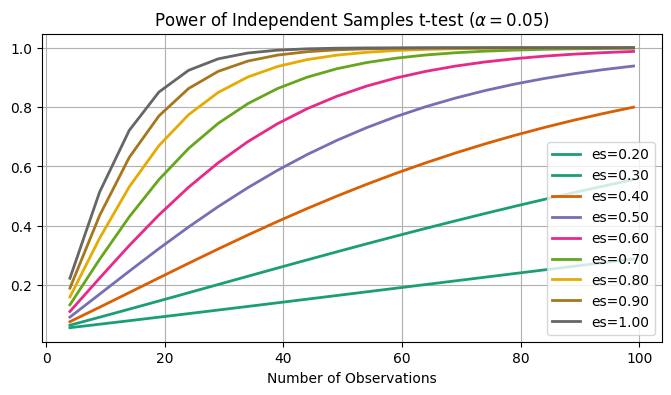

In [48]:
# plot a power curve (independent t test)

effect_sizes = np.linspace(start=0.2, stop=1.0, num=9)
sample_sizes = np.arange(start=4, stop=100, step=5)

fig, axes = plt.subplots()
fig.set_size_inches(8, 4)
sm.stats.TTestIndPower().plot_power(ax=axes, effect_size=effect_sizes, alpha=0.05, nobs=sample_sizes, dep_var="nobs", title=r"Power of Independent Samples t-test ($\alpha = 0.05$)")
axes.grid()
axes.set_axisbelow(True)
plt.show()

In [14]:
# power for a paired t test - determine the significance of differences in the means of two groups
sm.stats.TTestPower().solve_power(effect_size=0.5, power=0.8, alpha=0.05, nobs=None) # this gives the needed sample size

33.36713118431779

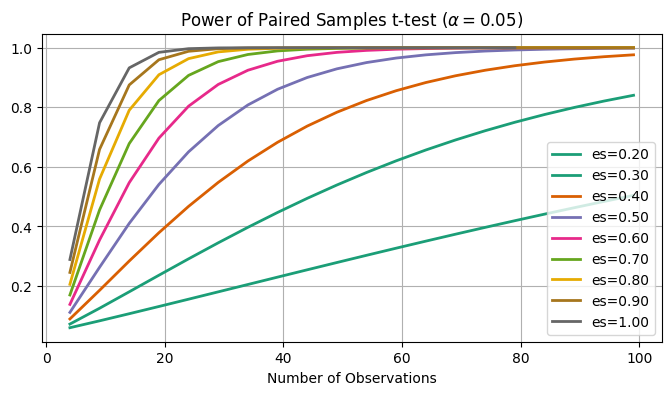

In [50]:
# plot a power curve (dependent t test)

effect_sizes = np.linspace(start=0.2, stop=1.0, num=9)
sample_sizes = np.arange(start=4, stop=100, step=5)

fig, axes = plt.subplots()
fig.set_size_inches(8, 4)
sm.stats.TTestPower().plot_power(ax=axes, effect_size=effect_sizes, alpha=0.05, nobs=sample_sizes, dep_var="nobs", title=r"Power of Paired Samples t-test ($\alpha = 0.05$)")
axes.grid()
axes.set_axisbelow(True)
plt.show()

### __`scipy`__

In [51]:
# using scipy, we can put the sample estimates of statsmodels to test

# let's look at the paired t test sample size, for a medium effect size (d = 0.5), alpha = 0.05 and a power of 80%
ssize = np.ceil(sm.stats.TTestPower().solve_power(effect_size=0.5, alpha=0.05, power=0.8, nobs)).astype(int)
ssize

np.int64(34)

In [52]:
np.random.normal(loc=0, scale=1, size=(2, 34))[0]

array([ 0.65316269,  2.05562944, -0.09736136,  0.21358477,  1.17308673,
       -0.16279579,  0.4851076 , -1.36967866,  0.66598608, -1.25070581,
       -1.84879629, -0.05018569, -1.23328798, -1.20388386, -1.20119037,
        0.50048307,  0.55884618,  0.32547399, -2.1561004 , -0.36879569,
       -1.36050664,  0.01006284, -0.92799142,  0.2749125 ,  1.18694094,
       -1.48045577,  0.91942582, -2.11968051, -0.14655575, -0.99508096,
       -0.96259456,  1.59616957,  1.57433112,  0.26732633])

In [74]:
# simulate two samples with size 34

def power_run_paired_ttest(niterations: int, sample_size: int, effect_size: float, rand_seed: Optional[int] = None) -> NDArray[np.float64]:
    
    """
    runs a repeated paired t test calculations and returns the p values of those calculations.
    niterations: int - number of times to repeat the paired t test calculations.
    sample_size: int - sample size for the randomly generated samples.
    effect_size: float - expected effect szie.
    rand_seed: custom seed to initialize the random number generator
    """

    if rand_seed is not None: # if a non None value is passed, seed the numpy random number generator with it
        np.random.seed(rand_seed)

    # we use ttest_rel here because our samples are related (have shared members) and we collect the p values across all iterations in an array and return it
    # we could take the first input out of the loop to improve performance, but this can lead to biased results since one array gets compared to all the other repeatedly generated
    # arrays, so if the first one is biased, that extends to all our iterations ....... yikes!
    GROUP_0 = np.random.normal(loc=0, scale=1, size=(niterations, sample_size))
    GROUP_1 = np.random.normal(loc=effect_size, scale=1, size=(niterations, sample_size))
    #  return np.array([stats.ttest_rel(a=np.random.normal(loc=0, scale=1, size=sample_size),
    #                                b=np.random.normal(loc=effect_size, scale=1, size=sample_size)).pvalue for _ in range(niterations)], dtype=np.float64)
    # not creating new arrays in a loop now :)
    # return np.array([stats.ttest_rel(a=GROUP_0[i], b=GROUP_1[i]).pvalue for i in range(niterations)], dtype=np.float64)
    # more randomization
    GROUP_0_IDX = np.random.choice(range(niterations), replace=False, size=niterations)
    GROUP_1_IDX = np.random.choice(range(niterations), replace=False, size=niterations)
    return np.array([stats.ttest_rel(a=GROUP_0[i], b=GROUP_1[j]).pvalue for (i, j) in zip(GROUP_0_IDX, GROUP_1_IDX)], dtype=np.float64)


In [72]:
pvals = power_run_paired_ttest(niterations=1000, sample_size=ssize, effect_size=0.8)
# on average (across all the iterations), the probability of our p value being significant (<0.05) is this result and if this is greater than our power of 0.8, we're good :)
(pvals < 0.05).mean() 

np.float64(0.884)

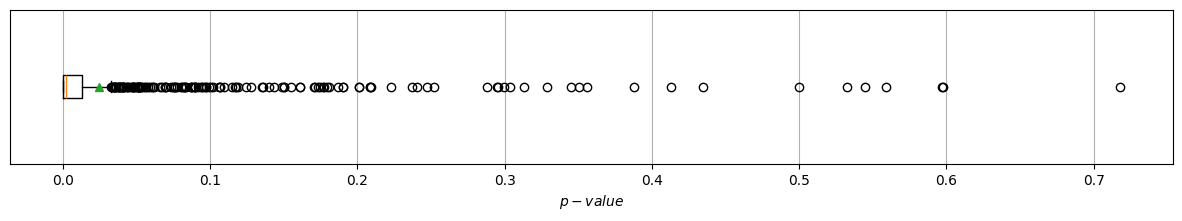

In [55]:
fig, axes = plt.subplots()
fig.set_size_inches(15, 2)
axes.boxplot(pvals, orientation="horizontal", showmeans=True)
axes.grid()
axes.set_xlabel(r"$p-value$")
axes.set_yticks([])
plt.show()

## ___Hypotheses___
---------------------

In [ ]:
# chapter 3 hypotheses

# Sympatric host ecotype – AM fungal community pairs will demonstrate superior adaptive fitness 
# (measured by total plant biomass, plant height, PRLC & total length of hyphae in gram soil) compared to their allopatric counterparts

# The extent of outsourcing reflected in the fine absorptive root traits (RD, SRL & RCT) will be the highest for each plant ecotype when paired with 
# sympatric AM fungal community compared to pairings with foreign AM fungal communities.

# Amongst the sympatric AM fungal-host ecotype pairs, the magnitude of this influence will be more pronounced where the hosts needed the AM fungi more (e.g. low phosphorus soils).

# The fine absorptive root traits (collaboration gradient) will also be influenced by the AM fungal community composition in the soil
# samples, but this influence will be less pronounced compared to the provenance specific coadaptations.

In [33]:
#-----------------------------------------------------------------------------------------------------------------------------------------------
# SINCE OUR ALLOPATRIC AND SYMPATRIC HOST & SYMBIONTS PAIRS WILL HAVE SHARED MEMBERS, WE CANNOT ASSUME THAT OUR TWO SAMPLES ARE INDEPENDENT
# WHAT WE NEED IS A DEPENDENT (PAIRED) t TEST
#-----------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
# first what statistical test will be best to analyze our data???

# hypo 1 - two sample t test
# hypo 2 - same, two sample t test

# BUT OUR GROUPS ARE NOT INDEPENDENT - 

# hypo 3 - linear regression??
# hypo 4 - a factorial ANOVA?? - two grouping variables => sympatry/allopatry and mycorrhizal community composition

In [2]:
themeda = pd.read_csv(r"./themeda_power.csv")
themeda.head()

,Accession,SRL,Diameter,annual_rainfall_mm,mean_annual_temp_celsius,ploidy_n,ammonium_nitrogen,nitrate_nitrogen,phosphorus_colwell,potassium_colwell,...,ph_level_cacl2,ph_level_h2o,total_nitrogen,total_phosphorus,total_carbon,prcnt_clay,prcnt_course_sand,prcnt_fine_sand,prcnt_sand,prcnt_silt
0,Dalby_QLD,16.292527,0.5521,621.4,27.0,6.0,6.0,0.0,18.0,398.0,...,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
1,Dalby_QLD,35.587354,0.4965,621.4,27.0,6.0,6.0,0.0,18.0,398.0,...,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
2,Dalby_QLD,26.271140,0.3816,621.4,27.0,6.0,6.0,0.0,18.0,398.0,...,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
3,Dalby_QLD,17.405689,0.6447,621.4,27.0,6.0,6.0,0.0,18.0,398.0,...,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
4,Mt_Fox_National_Park_QLD,35.094561,0.3699,642.8,29.3,4.0,6.0,0.0,6.0,314.0,...,5.7,6.7,0.19,157.5,2.66,21.60,33.49,22.22,55.71,22.69


In [151]:
scaled_x = StandardScaler().fit_transform(themeda.iloc[:, 3:])
scaled_x.shape

(24, 20)

In [155]:
y = themeda.iloc[:, 1:3].to_numpy()

In [157]:
lm = LinearRegression(n_jobs=8).fit(X=scaled_x, y=y)

In [159]:
lm.coef_ # [SRL, RD]

array([[ 5.69981143e-01, -2.00809027e+00, -8.29613045e-01,
        -1.51339582e-01, -9.29502498e-01, -1.64780879e+00,
         1.76847675e-03,  3.11138438e-01,  4.52683769e-01,
        -5.45854679e-01, -6.50447978e-01, -5.16001954e-01,
        -2.47201011e-01, -2.76501560e-01,  1.75951219e-01,
        -5.24222784e-02,  5.29546047e-01,  3.72335602e-01,
         5.86907116e-01, -9.21724919e-01],
       [-9.63435167e-04, -6.01010953e-03, -6.82558256e-03,
        -7.40743673e-03,  7.84460683e-03,  1.39024947e-03,
         4.92881835e-03,  1.23344200e-02,  5.49274049e-03,
         1.30047941e-02,  5.45266706e-03,  4.05984870e-03,
        -7.44840639e-04,  7.57836529e-03,  3.06738795e-03,
         2.86576806e-03, -4.17329772e-03,  1.62156549e-02,
        -1.16940481e-03, -2.30238852e-04]])

In [160]:
lm.intercept_

array([27.42545391,  0.52610729])

In [162]:
# linear model coefficients
pd.DataFrame(index=themeda.columns[3:], data=lm.coef_.T, columns=["SRL", "RD"])

,SRL,RD
annual_rainfall_mm,0.569981,-0.000963
mean_annual_temp_celsius,-2.008090,-0.006010
ploidy_n,-0.829613,-0.006826
ammonium_nitrogen,-0.151340,-0.007407
nitrate_nitrogen,-0.929502,0.007845
phosphorus_colwell,-1.647809,0.001390
potassium_colwell,0.001768,0.004929
sulfur,0.311138,0.012334
organic_carbon,0.452684,0.005493
conductivity,-0.545855,0.013005


In [174]:
# let's simulate a dataset for all these predictors and get a realistic projections for SRL and RD, which we can use in the power analysis

# step 1 - figure out what distribution each predictor variable is best represented by
# this can be accomplished using scipy.stats.kstest
# https://stackoverflow.com/questions/22392562/how-can-check-the-distribution-of-a-variable-in-python
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html#scipy.stats.kstest

# for pred in themeda.columns[3:]: print(themeda.loc[:, pred])

In [204]:
# let's look at MAP
MAP = fitter.Fitter(themeda.annual_rainfall_mm)
MAP.fit()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
powerlaw,0.001439,1636.185170,1639.719331,inf,0.632078,8.027761e-10
exponpow,0.001443,1693.293728,1696.827890,inf,0.513355,2.134382e-06
exponweib,0.001459,1831.338762,1836.050977,inf,0.636934,5.509852e-10
genextreme,0.001462,1866.485938,1870.020099,inf,0.574075,5.092710e-08
powerlognorm,0.001471,1794.807528,1799.519743,inf,0.446553,6.975855e-05


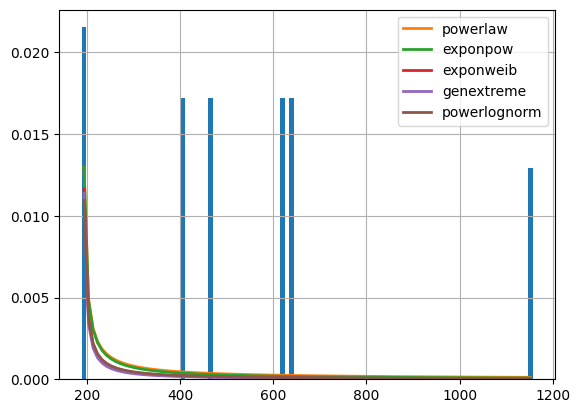

In [205]:
MAP.summary() # damn!

In [207]:
# THE ISSUE WITH USING PREDICTORS TO GENERATE THE PREDICTIONS (SRL & RD) IS THAT WE ONLY HAVE 6 UNIQUE VALUES FOR THE PREDICTORS
# NOT GOOD ENOUGH TO INFER THE TYPE OF DISTRIBUTION - BASED ON JUST 6 VALUES ?????
# THE IDEA SOUNDED GOOD BUT WE DO NOT HAVE ENOUGH DATA TO INFER THE DISTRIBUTION PATTERNS FOR THE PREDICTORS IN ORDER TO GENERATE MORE RECORDS TO HAVE MORE ROOT TRAIT PREDICTIONS
# THAT WE COULD USE IN POWER ANALYSIS

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
laplace_asymmetric,0.350721,794.961167,798.495328,inf,0.125128,0.802539
loglaplace,0.351325,835.417041,838.951203,inf,0.204855,0.232171
skewcauchy,0.352303,832.374469,835.908631,inf,0.151562,0.587384
exponnorm,0.352502,789.305627,792.839789,inf,0.127169,0.787001
landau,0.352967,810.748694,813.104802,inf,0.136140,0.715326


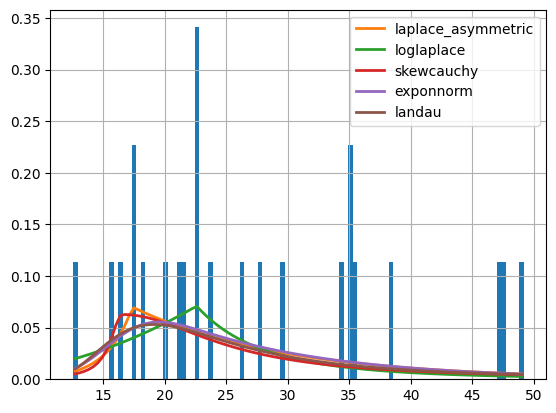

In [208]:
# INSTEAD FOCUS ON THE COLLABORATION AXIS ROOT TRAITS - JUST FIGURE OUT THEIR DISTRIBUTION PATTERN AND GENERATE DISTRIBUTIONS REPRESENTING THAT UNDERLYING DISTRIBUTION

SRL = fitter.Fitter(themeda.SRL)
SRL.fit()
SRL.summary()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
kappa4,1964.085477,-153.449738,-148.737522,inf,0.118415,0.850733
halfgennorm,1964.207024,-148.639812,-145.105650,inf,0.085653,0.988080
beta,1964.310955,-152.799193,-148.086978,inf,0.111829,0.892637
kappa3,1965.443242,-146.563612,-143.029451,inf,0.083079,0.991478
genhalflogistic,1965.820545,-139.547010,-136.012849,inf,0.128819,0.774194


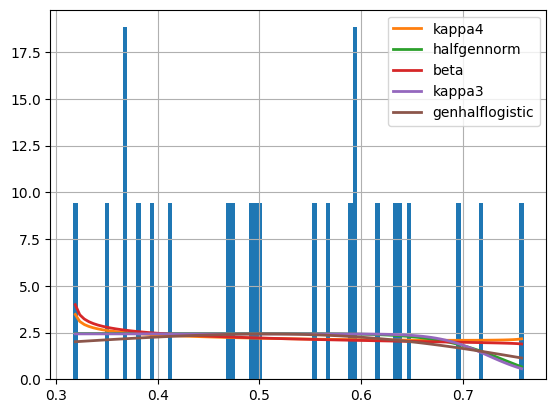

In [210]:
RD = fitter.Fitter(themeda.Diameter)
RD.fit()
RD.summary()

In [211]:
# even when we have 21 records for the response variables, IT IS JUST 21 RECORDS!!!
# best choices based on AICs
# SRL - exponnorm
# RD - kappa4

# but look at the plots???? - IDK??

In [8]:
# WHAT IF WE ASSUME NORMALITY???? - WE'D BE WRONG

print("SRL - ", stats.kstest(rvs=themeda.SRL, cdf=stats.norm.cdf, args=(themeda.SRL.min(), themeda.SRL.max())))
print("RD - ", stats.kstest(rvs=themeda.Diameter, cdf=stats.norm.cdf, args=(themeda.Diameter.min(), themeda.Diameter.max())))

SRL -  KstestResult(statistic=np.float64(0.5), pvalue=np.float64(4.503577714176448e-06), statistic_location=np.float64(12.55896802), statistic_sign=np.int8(-1))
RD -  KstestResult(statistic=np.float64(0.5), pvalue=np.float64(4.503577714176448e-06), statistic_location=np.float64(0.317), statistic_sign=np.int8(-1))


In [16]:
# Let's create two samples based on the highest and lowest site mean for SRL
sumstats = themeda.iloc[:, :3].groupby("Accession", as_index=True).agg(["mean", "std"])
sumstats

SRL             Diameter          
                               mean        std      mean       std
Accession                                                         
Dalby_QLD                 23.889177   8.986394  0.518725  0.109971
Mt_Fox_National_Park_QLD  27.673964   8.631141  0.459000  0.122623
Panawonica_WA             18.010786   4.721772  0.621800  0.204989
Rainbow_Valley_NT         28.718094  11.735060  0.501140  0.108094
Sydney_NSW                37.411013   9.127129  0.476333  0.109037
Virginia_Gardens_SA       31.022919  14.132250  0.573444  0.061289

In [225]:
# lowest SRL - Panawonica_WA
# highest SRL - Sydney_NSW

In [27]:
N_ITERS = 1000
SSIZE = 34
mean_srl_max_pos = np.argmax(sumstats.loc[:, ("SRL", "mean")])
mean_srl_min_pos = np.argmin(sumstats.loc[:, ("SRL", "mean")])

group_0 = np.random.normal(loc=sumstats.loc[:, ("SRL", "mean")].iloc[mean_srl_min_pos], scale=sumstats.loc[:, ("SRL", "std")].iloc[mean_srl_min_pos], size=(N_ITERS, SSIZE)) # Panawonica_WA
group_1 = np.random.normal(loc=sumstats.loc[:, ("SRL", "mean")].iloc[mean_srl_max_pos], scale=sumstats.loc[:, ("SRL", "std")].iloc[mean_srl_max_pos], size=(N_ITERS, SSIZE)) # Sydney_NSW

pvs = np.array([stats.ttest_rel(a=group_0[i], b=group_1[i]).pvalue for i in range(N_ITERS)], dtype=np.float64)
(pvs < 0.05).mean()

np.float64(1.0)

In [233]:
# 34 seems like a good number :)
# NOW WE NEED TO DECIDE HOW TO PARTITION THIS 34 INTO HOST ECOTYPE - SOIL PAIRS
# 34 SYMPATRIC PAIRS
# 34 ALLOPATRIC PAIRS

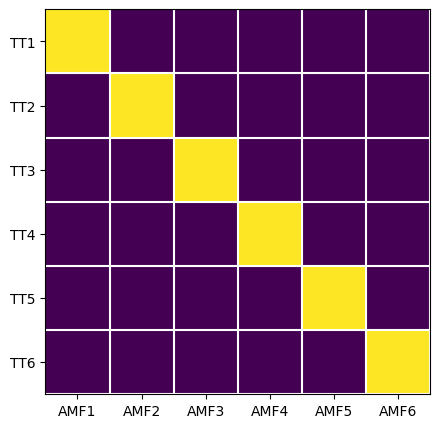

In [42]:
fig, axes = plt.subplots()
axes.imshow(np.eye(N=6, M=6))
fig.set_size_inches(5, 5)
axes.set_xticks(ticks=np.linspace(start=0, stop=5, num=6), labels=[f"AMF{i}" for i in range(1, 7)])
axes.vlines(x=np.linspace(start=0.5, stop=5.5, num=6), ymin=axes.get_ylim()[0], ymax=axes.get_ylim()[1], colors="white")
axes.set_yticks(ticks=np.linspace(start=0, stop=5, num=6), labels=[f"TT{i}" for i in range(1, 7)])
axes.hlines(y=np.linspace(start=0.5, stop=5.5, num=6), xmin=axes.get_xlim()[0], xmax=axes.get_xlim()[1], colors="white")
plt.show()

In [ ]:
# if we decide to go with 34, we can safely increase that to 36, so it's divisible by our number of treatments = 6
# NUMBER OF TREATMENTS = 6
# NUMBER OF BLOCKS = 6
# 

In [ ]:
# CAN WE ACTUALLY USE A PAIRED t test FOR THIS??? OUR MEASUREMENTS AREN'T REPEATED MEASUREMENTS ON THE SAME SAMPLE?????


In [ ]:
# https://stats.oarc.ucla.edu/r/whatstat/what-statistical-analysis-should-i-usestatistical-analyses-using-r/#1repanovA

In [46]:
# let's hope this gets answered
# https://stats.stackexchange.com/questions/674034/statistical-test-for-significance-of-mean-differences-between-two-groups